In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
df = pd.read_csv("../data/raw/task2_sentiment_analysis.csv")

df.head()

,review_id,review,sentiment_label,sentiment_score,identified_theme
0,1,yoroo namaste 🙏 ♥️ ❤️ 💖 💖,NEGATIVE,0.890468,Other
1,2,incredible,POSITIVE,0.999875,Other
2,3,best app for financial sector,POSITIVE,0.999166,Other
3,4,it's a good application,POSITIVE,0.999866,Other
4,5,thank you cbe,POSITIVE,0.999756,Other


In [5]:
df.columns

Index(['review_id', 'review', 'sentiment_label', 'sentiment_score',
       'identified_theme'],
      dtype='str')

In [6]:
# Load cleaned review dataset
reviews_df = pd.read_csv(
    "../data/raw/fintech_reviews_clean.csv"
)

# Load sentiment analysis dataset
sentiment_df = pd.read_csv(
    "../data/raw/task2_sentiment_analysis.csv"
)

# Merge datasets
df = pd.concat(
    [reviews_df, sentiment_df],
    axis=1
)

# Remove duplicated review column if needed
df = df.loc[:, ~df.columns.duplicated()]

# Preview columns
print(df.columns)

Index(['review', 'rating', 'date', 'bank', 'source', 'review_id',
       'sentiment_label', 'sentiment_score', 'identified_theme'],
      dtype='str')


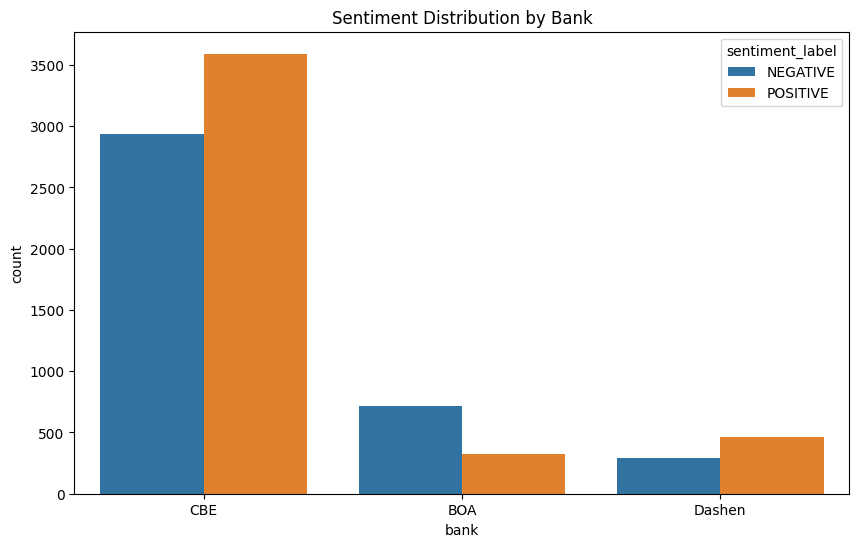

In [7]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="bank",
    hue="sentiment_label"
)

plt.title("Sentiment Distribution by Bank")

plt.show()

## Sentiment Distribution by Bank — Analysis

The chart compares positive and negative customer sentiments across CBE, BOA, and Dashen Bank mobile applications.

- **CBE** received the highest number of reviews overall, with positive sentiment slightly higher than negative sentiment. This suggests strong customer engagement and general satisfaction, although many users still reported issues such as slow transfers and app crashes.

- **BOA** shows a higher proportion of negative reviews compared to positive ones, indicating customer dissatisfaction mainly related to login problems, OTP failures, and poor app stability.

- **Dashen Bank** demonstrates a more balanced sentiment distribution with more positive than negative reviews, suggesting relatively stable customer satisfaction and better application performance compared to BOA.

### Overall Insight

The analysis indicates that application reliability, transaction speed, and authentication performance are major factors influencing customer satisfaction across Ethiopian banking apps. Users respond positively to smooth and fast banking experiences, while technical failures strongly contribute to negative sentiment.

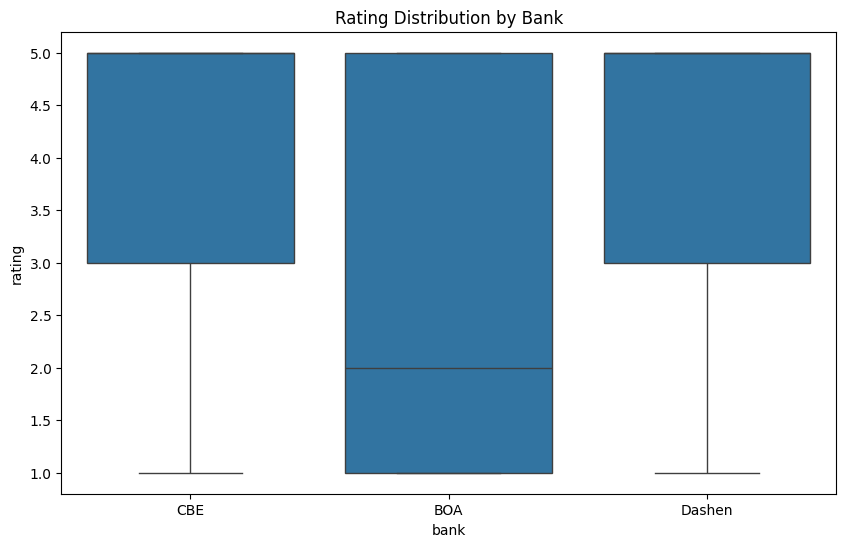

In [8]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="bank",
    y="rating"
)

plt.title("Rating Distribution by Bank")

plt.show()

## Rating Distribution by Bank — Analysis

The boxplot compares the distribution of user ratings across CBE, BOA, and Dashen Bank mobile applications.

- **CBE** and **Dashen Bank** show higher median ratings, with most reviews concentrated between 3 and 5 stars. This indicates relatively strong customer satisfaction and more consistent user experiences.

- **BOA** has a noticeably lower median rating and wider rating spread, suggesting inconsistent service quality and a larger number of dissatisfied users.

- The presence of low ratings across all banks indicates that users still experience technical or usability issues, but these issues appear to be more severe and frequent for BOA.

### Overall Insight

The rating distribution aligns closely with the sentiment analysis results. CBE and Dashen Bank maintain generally positive customer experiences, while BOA faces greater customer dissatisfaction likely driven by recurring technical problems such as login issues, OTP failures, and application instability.

In [9]:
theme_counts = (
    df.groupby(["bank", "identified_theme"])
      .size()
      .reset_index(name="count")
)

theme_counts.head()

,bank,identified_theme,count
0,BOA,Account Access Issues,34
1,BOA,Other,916
2,BOA,Transaction Performance,68
3,BOA,UI & Design,22
4,CBE,Account Access Issues,27


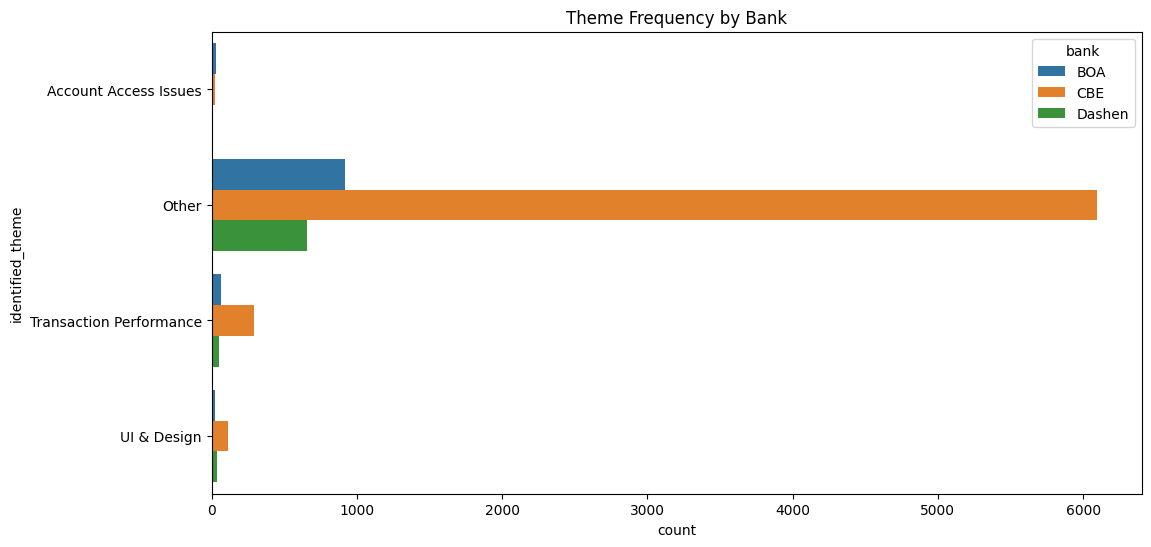

In [10]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=theme_counts,
    x="count",
    y="identified_theme",
    hue="bank"
)

plt.title("Theme Frequency by Bank")

plt.show()

## Theme Frequency by Bank — Analysis

The chart illustrates the frequency of major review themes identified across CBE, BOA, and Dashen Bank mobile applications.

- The **"Other"** category dominates across all three banks, especially for **CBE**, indicating that many customer reviews contain general feedback, mixed opinions, or issues that do not fall into predefined themes.

- **Transaction Performance** appears as a noticeable concern, particularly for CBE, suggesting that users frequently experience slow transfers, delayed processing, or transaction-related issues.

- **UI & Design** issues are present across the banks but at lower frequencies, indicating that while interface usability matters to users, technical reliability remains a more significant concern.

- **Account Access Issues** such as login failures and OTP problems appear less frequently in the dataset but still represent important customer frustrations, especially for BOA.

### Overall Insight

The analysis suggests that transaction reliability and overall application performance are the most discussed issues across Ethiopian banking apps. While users appreciate functional mobile banking services, recurring technical and performance-related complaints continue to affect customer satisfaction.

In [13]:
df["date"] = pd.to_datetime(df["date"])

trend = (
    df.groupby(
        [
            "date",
            "sentiment_label"
        ]
    )
    .size()
    .reset_index(name="count")
)


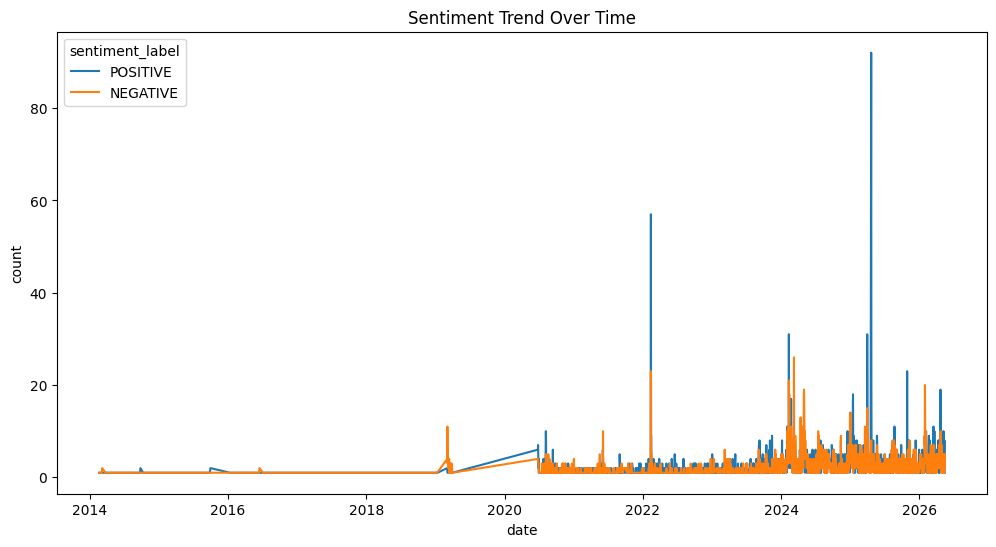

In [14]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=trend,
    x="date",
    y="count",
    hue="sentiment_label"
)

plt.title("Sentiment Trend Over Time")

plt.show()

## Sentiment Trend Over Time — Analysis

The chart shows how positive and negative customer sentiments changed over time across the collected banking app reviews.

- Positive sentiment generally remains higher than negative sentiment throughout most of the timeline, indicating that many users had satisfactory experiences with the mobile banking applications.

- Several noticeable spikes in both positive and negative sentiment appear between 2022 and 2026, suggesting periods of increased user engagement, app updates, or technical incidents that triggered more customer feedback.

- The sharp increase in negative sentiment during certain periods may reflect recurring issues such as login failures, transaction delays, OTP problems, or application crashes.

- Positive sentiment spikes likely correspond to successful feature updates, improved app performance, or enhanced customer experience improvements.

### Overall Insight

The trend analysis indicates that customer sentiment is highly influenced by application performance and service reliability over time. Periods of technical instability tend to generate immediate negative feedback, while successful updates and smooth transaction experiences contribute to stronger positive sentiment.

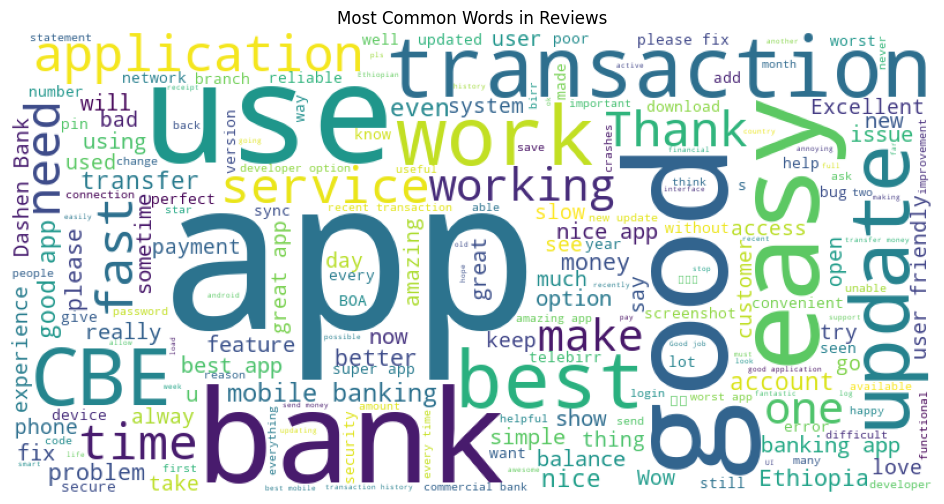

In [15]:
from wordcloud import WordCloud

text = " ".join(df["review"].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Common Words in Reviews")

plt.show()

## Word Cloud Analysis — Most Common Words in Reviews

The word cloud highlights the most frequently used terms across customer reviews from the three banking applications.

- Words such as **"app"**, **"bank"**, **"transaction"**, **"service"**, and **"working"** appear most prominently, indicating that users mainly discuss application performance and banking services.

- Positive terms including **"best"**, **"good"**, **"excellent"**, **"nice"**, and **"thank"** suggest that many users appreciate the convenience and usefulness of the mobile banking applications.

- At the same time, words such as **"problem"**, **"slow"**, **"fix"**, and **"issue"** reveal recurring customer frustrations related to technical reliability and transaction performance.

- Terms like **"transfer"**, **"balance"**, **"account"**, and **"payment"** indicate that customers frequently review core banking functionalities.

### Overall Insight

The word cloud shows that customer feedback is strongly centered around application usability, transaction efficiency, and service reliability. While many users express satisfaction with the banking apps, technical issues and performance-related concerns remain important areas for improvement.

## Word Cloud Analysis — Most Common Words in Reviews

The word cloud highlights the most frequently used terms across customer reviews from the three banking applications.

- Words such as **"app"**, **"bank"**, **"transaction"**, **"service"**, and **"working"** appear most prominently, indicating that users mainly discuss application performance and banking services.

- Positive terms including **"best"**, **"good"**, **"excellent"**, **"nice"**, and **"thank"** suggest that many users appreciate the convenience and usefulness of the mobile banking applications.

- At the same time, words such as **"problem"**, **"slow"**, **"fix"**, and **"issue"** reveal recurring customer frustrations related to technical reliability and transaction performance.

- Terms like **"transfer"**, **"balance"**, **"account"**, and **"payment"** indicate that customers frequently review core banking functionalities.

### Overall Insight

The word cloud shows that customer feedback is strongly centered around application usability, transaction efficiency, and service reliability. While many users express satisfaction with the banking apps, technical issues and performance-related concerns remain important areas for improvement.

## Pain Points

### CBE
- Slow transaction processing
- Occasional application crashes

### BOA
- OTP verification failures
- Login and authentication problems

### Dashen Bank
- App freezing during usage
- Network-related transaction delays

## Cross-Bank Comparison

| Bank | Sentiment Performance | Main Strength | Main Weakness |
|---|---|---|---|
| CBE | Mostly Positive | Large user adoption | Performance issues |
| BOA | Mostly Negative | Banking functionality | Login and OTP issues |
| Dashen | Moderately Positive | Stable experience | Limited feature innovation |

## Recommendations

### Commercial Bank of Ethiopia (CBE)
- Optimize transaction processing speed to reduce delays during transfers.
- Improve application stability and crash monitoring systems.

### Bank of Abyssinia (BOA)
- Redesign the OTP verification and authentication workflow.
- Strengthen application reliability and bug fixing processes.

### Dashen Bank
- Enhance network performance handling during transactions.
- Introduce additional customer-requested features such as biometric login.

## Ethical Considerations

Several limitations and biases may affect the interpretation of the review data:

- Users are more likely to leave reviews after negative experiences, creating negativity bias.
- The dataset may not represent all users equally.
- Some reviews contain mixed languages and emojis that may affect sentiment classification accuracy.
- Review availability on Google Play changes over time.

## Conclusion

The analysis reveals that customer satisfaction across Ethiopian banking applications is heavily influenced by application reliability, transaction performance, and authentication stability.

CBE demonstrates strong customer adoption but faces scalability-related technical challenges. BOA shows the highest level of customer dissatisfaction driven by login and OTP issues. Dashen Bank maintains relatively stable customer satisfaction with fewer severe complaints.

Overall, improving transaction reliability, reducing technical failures, and enhancing user experience should be prioritized by all three banks to remain competitive in Ethiopia’s growing fintech ecosystem.